# Physics-Based 3D Wind Mapping from Drone ROS Bags with PyVista

## What the notebook uses

- `/nav/odom`: longitude, latitude, altitude, quaternion attitude, and body-frame velocity
- `/imu/data`: IMU acceleration and angular velocity for diagnostics
- `/battery`: voltage and current
- `/anemometer`: **not used to calculate wind**; retained only for optional validation

## Physics model

1. Rotate body-frame velocity and thrust into an east–north–up frame.
2. Smooth velocity and differentiate it to obtain acceleration.
3. Estimate total rotor thrust from electrical power using actuator-disk momentum-theory scaling:

\[
T \approx mg\left(\frac{P_{prop}}{P_{hover}}\right)^{2/3}
\]

4. Use Newton's second law to isolate the aerodynamic force:

\[
\vec F_{aero}=m\vec a-\vec F_{thrust}-\vec F_g
\]

5. Use an axis-specific quadratic drag model:

\[
F_{D,i}=-\frac12\rho(C_DA)_i\left|v_{rel,i}\right|v_{rel,i}
\]

6. Invert the drag equation and recover ambient wind:

\[
\vec v_{wind}=\vec v_{ground}-\vec v_{relative\ air}
\]

7. Interpolate the calculated vectors onto a PyVista `ImageData` grid, then render arrows and streamlines.



## Cell 1 — Install ROS-bag, scientific-computing, and PyVista packages

In [3]:
# Colab needs an off-screen display for VTK/PyVista static rendering.
!apt-get update -qq
!apt-get install -qq xvfb libgl1-mesa-glx libosmesa6

# PyVista 0.48.4 matches the API used in this notebook.
!pip install -q pyvista==0.48.4 rosbags scipy pandas numpy matplotlib trame trame-vtk trame-vuetify tqdm scikit-learn nest_asyncio2

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../0-libegl-mesa0_23.2.1-1ubuntu3.1~22.04.4_amd64.deb ...
Unpacking libegl-mesa0:amd64 (23.2.1-1ubuntu3.1~22.04.4) over (23.2.1-1ubuntu3.1~22.04.3) ...
Preparing to unpack .../1-libgbm1_23.2.1-1ubuntu3.1~22.04.4_amd64.deb ...
Unpacking libgbm1:amd64 (23.2.1-1ubuntu3.1~22.04.4) over (23.2.1-1ubuntu3.1~22.04.3) ...
Preparing to unpack .../2-libgl1-mesa-dri_23.2.1-1ubuntu3.1~22.04.4_amd64.deb ...
Unpacking libgl1-mesa-dri:amd64 (23.2.1-1ubuntu3.1~22.04.4) over (23.2.1-1ubuntu3.1~22.04.3) ...
Preparing to unpack .../3-libglx-mesa0_23.2.1-1ubuntu3.1~22.04.4_amd64.deb ...
Unpacking libglx-mesa0:amd64 (23.2.1-1ubuntu3.1~22.04.4) over (23.2.1-1ubuntu3.1~22.04.3) ...
Preparing to unpack .../4-libglapi-mesa_23.2.1-1ub

## Cell 2 — Imports and PyVista setup

In [4]:
from pathlib import Path
from typing import Dict, Iterable, Optional, Tuple
import math
import shutil
import warnings
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.spatial.transform import Rotation
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tqdm.auto import tqdm
from IPython.display import display

import pyvista as pv
from rosbags.highlevel import AnyReader

# Static rendering is the most reliable PyVista mode in Google Colab.
pv.set_jupyter_backend("static")
pv.global_theme.notebook = True
#pv.start_xvfb()

pd.set_option("display.max_columns", 100)
np.set_printoptions(suppress=True, precision=4)

print("PyVista version:", pv.__version__)

PyVista version: 0.48.4


## Cell 3 — Upload `raw_files.zip` and extract it

In [6]:
from pathlib import Path
import shutil
import zipfile
from google.colab import files

# Change this path when the ZIP is already in Google Drive or /content.
RAW_ZIP = Path("/content/raw_files.zip")
EXTRACT_DIR = Path("/content/drone_raw_data")

# Helper function to check if a file is a valid zip
def is_valid_zip(file_path):
    if not file_path.exists():
        return False
    try:
        with zipfile.ZipFile(file_path, 'r') as zf:
            return zf.testzip() is None # testzip() returns None on success
    except zipfile.BadZipFile:
        return False
    except Exception: # Catch other potential errors during zip opening
        return False

# If the RAW_ZIP does not exist or is not a valid zip file, prompt for upload
if not is_valid_zip(RAW_ZIP):
    # If an invalid file exists at RAW_ZIP, remove it before uploading
    if RAW_ZIP.exists():
        RAW_ZIP.unlink()
        print(f"Removed existing invalid file at {RAW_ZIP} to allow re-upload.")

    print("Upload raw_files.zip")
    uploaded = files.upload()
    uploaded_names = list(uploaded)
    if not uploaded_names:
        raise FileNotFoundError("No ZIP file was uploaded.")
    uploaded_path = Path("/content") / uploaded_names[0]
    if uploaded_path != RAW_ZIP:
        shutil.move(str(uploaded_path), RAW_ZIP)
    # After upload, verify the newly uploaded file
    if not is_valid_zip(RAW_ZIP):
        raise ValueError("The uploaded file is not a valid ZIP file. Please ensure you upload a valid 'raw_files.zip'.")


EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
with zipfile.ZipFile(RAW_ZIP, "r") as archive:
    archive.extractall(EXTRACT_DIR)

BAG_FILES = sorted(
    EXTRACT_DIR.rglob("*.bag"),
    key=lambda p: int(p.parent.name) if p.parent.name.isdigit() else p.as_posix(),
)

print(f"Found {len(BAG_FILES)} ROS bag files")
print("First five:")
for path in BAG_FILES[:5]:
    print(" ", path)

if not BAG_FILES:
    raise FileNotFoundError("No .bag files were found after extracting the ZIP.")

Upload raw_files.zip


Saving raw_files (1).zip to raw_files (1).zip
Found 207 ROS bag files
First five:
  /content/drone_raw_data/raw/1/raw.bag
  /content/drone_raw_data/raw/2/raw.bag
  /content/drone_raw_data/raw/3/raw.bag
  /content/drone_raw_data/raw/4/raw.bag
  /content/drone_raw_data/raw/5/raw.bag


## Cell 4 — User settings and physical constants


1. Put a `parameters.csv` in `/content` and set `PARAMETERS_CSV`.
2. Fill `FLIGHT_PAYLOAD_KG` manually for selected flights.
3. Use `DEFAULT_PAYLOAD_KG` as a fallback.



In [7]:
# ----------------------------
# DATA PROCESSING SETTINGS
# ----------------------------
SYNC_HZ = 5.0                 # Match the approximately 5 Hz synchronized dataset
SYNC_TOLERANCE_S = 0.16       # Maximum nearest-message time difference
SMOOTHING_SECONDS = 2.2       # Savitzky-Golay window for velocity/acceleration
WIND_SMOOTHING_SECONDS = 1.4  # Final wind-vector smoothing

# Set to an integer such as 3 while testing. Use None to process every bag.
MAX_FLIGHTS = None

# ----------------------------
# AIRFRAME MASS
# ----------------------------
BASE_DRONE_MASS_KG = 3.680
DEFAULT_PAYLOAD_KG = 0.0

# Example: {18: 0.250, 129: 0.500}
FLIGHT_PAYLOAD_KG: Dict[int, float] = {}

# Optional official flight-parameter CSV, when available.
PARAMETERS_CSV: Optional[Path] = None
# Example: PARAMETERS_CSV = Path("/content/parameters.csv")

# ----------------------------
# AERODYNAMIC PARAMETERS
# ----------------------------
# CdA means drag coefficient times projected area, in m^2.
# These are initial guesses and should be calibrated experimentally.
CDA_BODY_X_M2 = 0.18  # forward/backward
CDA_BODY_Y_M2 = 0.18  # sideways
CDA_BODY_Z_M2 = 0.32  # vertical
CDA_BODY_M2 = np.array([CDA_BODY_X_M2, CDA_BODY_Y_M2, CDA_BODY_Z_M2])

GRAVITY_MPS2 = 9.80665
EARTH_RADIUS_M = 6_371_000.0

# ----------------------------
# QUALITY FILTERS
# ----------------------------
MIN_ALTITUDE_AGL_M = 5.0
MAX_ACCELERATION_MPS2 = 4.0
MAX_ANGULAR_RATE_RAD_S = 1.0
MAX_TILT_DEG = 35.0
MAX_WIND_SPEED_MPS = 25.0

# Outputs
OUTPUT_DIR = Path("/content/physics_wind_output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## Cell 5 — Helpers for timestamps, flight IDs, and optional payload metadata

In [8]:
def message_time_seconds(message, bag_timestamp_ns: int) -> float:
    '''Prefer the ROS header timestamp; fall back to the bag timestamp.'''
    try:
        stamp = message.header.stamp
        return float(stamp.sec) + float(stamp.nanosec) * 1e-9
    except Exception:
        return float(bag_timestamp_ns) * 1e-9


def flight_id_from_path(bag_path: Path) -> int:
    '''The parent folder in this dataset is the numeric flight ID.'''
    try:
        return int(bag_path.parent.name)
    except ValueError as exc:
        raise ValueError(f"Could not read flight ID from {bag_path}") from exc


def normalize_name(name: str) -> str:
    return "".join(ch.lower() if ch.isalnum() else "_" for ch in str(name)).strip("_")


def load_payload_map(parameters_csv: Optional[Path]) -> Dict[int, float]:
    '''Load flight payloads from a flexible parameters CSV when supplied.'''
    if parameters_csv is None or not Path(parameters_csv).exists():
        return {}

    params = pd.read_csv(parameters_csv)
    normalized = {normalize_name(col): col for col in params.columns}

    flight_aliases = ["flight", "flight_id", "flight_number", "id"]
    payload_aliases = [
        "payload_kg", "payload_mass_kg", "payload", "payload_mass",
        "payload_g", "payload_mass_g", "weight_g",
    ]

    flight_col = next((normalized[a] for a in flight_aliases if a in normalized), None)
    payload_col = next((normalized[a] for a in payload_aliases if a in normalized), None)

    if flight_col is None or payload_col is None:
        warnings.warn(
            "The parameters CSV was found, but flight/payload columns were not recognized. "
            "Use FLIGHT_PAYLOAD_KG instead."
        )
        return {}

    flight_values = pd.to_numeric(params[flight_col], errors="coerce")
    payload_values = pd.to_numeric(params[payload_col], errors="coerce")

    payload_name = normalize_name(payload_col)
    if payload_name.endswith("_g") or "mass_g" in payload_name or "weight_g" in payload_name:
        payload_values = payload_values / 1000.0

    mapping = {
        int(fid): float(payload)
        for fid, payload in zip(flight_values, payload_values)
        if np.isfinite(fid) and np.isfinite(payload)
    }
    print(f"Loaded payload metadata for {len(mapping)} flights")
    return mapping


CSV_PAYLOAD_MAP = load_payload_map(PARAMETERS_CSV)

def mass_for_flight(flight_id: int) -> float:
    payload = FLIGHT_PAYLOAD_KG.get(
        flight_id,
        CSV_PAYLOAD_MAP.get(flight_id, DEFAULT_PAYLOAD_KG),
    )
    return BASE_DRONE_MASS_KG + float(payload)

## Cell 6 — Extract and synchronize one ROS bag


- converts ROS messages to numeric columns;
- creates timestamps and elapsed time;
- converts quaternions to roll, pitch, and yaw in radians;
- normalizes wind angle to `[0, 360)`;
- preserves battery voltage/current;
- removes exact duplicates;
- reports missing data rather than inventing it.


In [9]:
def empty_topic_frames() -> Dict[str, list]:
    return {"odom": [], "imu": [], "battery": [], "anemometer": []}


def extract_topic_rows(bag_path: Path) -> Dict[str, pd.DataFrame]:
    '''Read the four known topics from one ROS1 bag.'''
    records = empty_topic_frames()

    with AnyReader([bag_path]) as reader:
        for connection, bag_time_ns, rawdata in reader.messages():
            message = reader.deserialize(rawdata, connection.msgtype)
            timestamp = message_time_seconds(message, bag_time_ns)

            if connection.topic == "/nav/odom":
                position = message.pose.pose.position
                quaternion = message.pose.pose.orientation
                linear = message.twist.twist.linear
                angular = message.twist.twist.angular
                records["odom"].append([
                    timestamp,
                    position.x, position.y, position.z,
                    quaternion.x, quaternion.y, quaternion.z, quaternion.w,
                    linear.x, linear.y, linear.z,
                    angular.x, angular.y, angular.z,
                ])

            elif connection.topic == "/imu/data":
                quaternion = message.orientation
                acceleration = message.linear_acceleration
                angular = message.angular_velocity
                records["imu"].append([
                    timestamp,
                    quaternion.x, quaternion.y, quaternion.z, quaternion.w,
                    acceleration.x, acceleration.y, acceleration.z,
                    angular.x, angular.y, angular.z,
                ])

            elif connection.topic == "/battery":
                records["battery"].append([
                    timestamp, message.voltage, message.current,
                ])

            elif connection.topic == "/anemometer":
                records["anemometer"].append([
                    timestamp, message.speed, message.angle,
                ])

    frames = {
        "odom": pd.DataFrame(records["odom"], columns=[
            "Timestamp", "X", "Y", "Z",
            "Qx", "Qy", "Qz", "Qw",
            "Body_velocity_x", "Body_velocity_y", "Body_velocity_z",
            "Body_rate_x", "Body_rate_y", "Body_rate_z",
        ]),
        "imu": pd.DataFrame(records["imu"], columns=[
            "Timestamp", "IMU_Qx", "IMU_Qy", "IMU_Qz", "IMU_Qw",
            "IMU_accel_x", "IMU_accel_y", "IMU_accel_z",
            "IMU_rate_x", "IMU_rate_y", "IMU_rate_z",
        ]),
        "battery": pd.DataFrame(records["battery"], columns=[
            "Timestamp", "Battery_V", "Battery_C",
        ]),
        "anemometer": pd.DataFrame(records["anemometer"], columns=[
            "Timestamp", "Wind_speed", "Wind_angle",
        ]),
    }

    for name, frame in frames.items():
        if frame.empty:
            raise ValueError(f"{bag_path.name}: required topic '{name}' is empty")
        frame.drop_duplicates(inplace=True)
        frame.sort_values("Timestamp", inplace=True)
        frame.drop_duplicates(subset="Timestamp", keep="first", inplace=True)
        frame.reset_index(drop=True, inplace=True)

    return frames


def synchronize_topics(
    frames: Dict[str, pd.DataFrame],
    frequency_hz: float = SYNC_HZ,
    tolerance_s: float = SYNC_TOLERANCE_S,
) -> pd.DataFrame:
    '''Nearest-neighbor ApproximateTime-style synchronization onto a fixed grid.'''
    start_time = max(frame["Timestamp"].min() for frame in frames.values())
    end_time = min(frame["Timestamp"].max() for frame in frames.values())

    if not np.isfinite(start_time) or not np.isfinite(end_time) or end_time <= start_time:
        raise ValueError("The topic time ranges do not overlap.")

    first_grid_time = math.ceil(start_time * frequency_hz) / frequency_hz
    last_grid_time = math.floor(end_time * frequency_hz) / frequency_hz
    grid_times = np.arange(first_grid_time, last_grid_time + 0.5 / frequency_hz, 1.0 / frequency_hz)
    synchronized = pd.DataFrame({"Timestamp": grid_times})

    for topic_name in ["odom", "imu", "battery", "anemometer"]:
        synchronized = pd.merge_asof(
            synchronized.sort_values("Timestamp"),
            frames[topic_name].sort_values("Timestamp"),
            on="Timestamp",
            direction="nearest",
            tolerance=tolerance_s,
        )

    return synchronized


def standardize_one_bag(bag_path: Path) -> pd.DataFrame:
    '''Create standardized and physics-support columns for one flight.'''
    flight_id = flight_id_from_path(bag_path)
    frames = extract_topic_rows(bag_path)
    data = synchronize_topics(frames)

    numeric_columns = [col for col in data.columns if col != "Timestamp"]
    for column in numeric_columns:
        data[column] = pd.to_numeric(data[column], errors="coerce")

    required = [
        "X", "Y", "Z", "Qx", "Qy", "Qz", "Qw",
        "Body_velocity_x", "Body_velocity_y", "Body_velocity_z",
        "Battery_V", "Battery_C",
    ]
    data.dropna(subset=required, inplace=True)

    # Basic physical-range validation. This removes impossible/corrupt readings,
    # not statistical outliers from otherwise plausible flight behavior.
    valid_range = (
        data["X"].between(-180.0, 180.0)
        & data["Y"].between(-90.0, 90.0)
        & data["Z"].between(-500.0, 10_000.0)
        & data["Battery_V"].between(0.0, 35.0)
        & data["Battery_C"].between(-10.0, 200.0)
    )
    data = data.loc[valid_range].copy()

    quaternion = data[["Qx", "Qy", "Qz", "Qw"]].to_numpy(dtype=float)
    quaternion_norm = np.linalg.norm(quaternion, axis=1)
    valid_quaternion = np.isfinite(quaternion_norm) & (quaternion_norm > 0.5)
    data = data.loc[valid_quaternion].copy()
    quaternion = quaternion[valid_quaternion] / quaternion_norm[valid_quaternion, None]
    data[["Qx", "Qy", "Qz", "Qw"]] = quaternion

    rotation = Rotation.from_quat(quaternion)
    euler_xyz = rotation.as_euler("xyz", degrees=False)
    data[["Roll", "Pitch", "Yaw"]] = euler_xyz

    # The odometry twist is body-frame velocity in these bags. Rotate it into ENU.
    body_velocity = data[[
        "Body_velocity_x", "Body_velocity_y", "Body_velocity_z"
    ]].to_numpy(dtype=float)
    velocity_enu = rotation.apply(body_velocity)
    data[["Velocity_East_mps", "Velocity_North_mps", "Velocity_Up_mps"]] = velocity_enu

    # Geographic coordinates -> local east/north/up coordinates.
    longitude_0 = float(data["X"].iloc[0])
    latitude_0 = float(data["Y"].iloc[0])
    altitude_0 = float(data["Z"].iloc[0])
    mean_latitude_rad = np.deg2rad((data["Y"] + latitude_0) / 2.0)

    data["Local_east_m"] = (
        EARTH_RADIUS_M
        * np.deg2rad(data["X"] - longitude_0)
        * np.cos(mean_latitude_rad)
    )
    data["Local_north_m"] = EARTH_RADIUS_M * np.deg2rad(data["Y"] - latitude_0)
    data["Relative_altitude_m"] = data["Z"] - altitude_0

    data["Wind_angle"] = data["Wind_angle"] % 360.0
    data["Flight_ID"] = flight_id
    data["Elapsed_s"] = data["Timestamp"] - data["Timestamp"].iloc[0]
    data["Source_dataset"] = "CMU_Matrice100_raw_rosbag"
    data["Coordinate_frame"] = "geographic_WGS84_with_local_ENU"
    data["Drone_mass_kg"] = mass_for_flight(flight_id)

    # Match the standardized ML-column ordering first, then preserve physics columns.
    leading_columns = [
        "Timestamp", "X", "Y", "Z", "Roll", "Pitch", "Yaw",
        "Wind_speed", "Wind_angle", "Source_dataset", "Battery_V", "Battery_C",
        "Flight_ID", "Elapsed_s", "Coordinate_frame",
    ]
    remaining_columns = [col for col in data.columns if col not in leading_columns]
    data = data[leading_columns + remaining_columns]

    data.drop_duplicates(inplace=True)
    data.sort_values("Timestamp", inplace=True)
    data.reset_index(drop=True, inplace=True)
    return data

## Cell 7 — Test the cleaning pipeline on one flight

In [10]:
TEST_BAG = BAG_FILES[0]
test_clean = standardize_one_bag(TEST_BAG)

print("Flight:", test_clean["Flight_ID"].iloc[0])
print("Rows:", len(test_clean))
display(test_clean.head())
display(test_clean[[
    "X", "Y", "Z", "Roll", "Pitch", "Yaw",
    "Battery_V", "Battery_C", "Wind_speed"
]].describe())

# Missing-value report
missing_fraction = test_clean.isna().mean().sort_values(ascending=False)
display(missing_fraction[missing_fraction > 0].to_frame("missing_fraction"))

Flight: 1
Rows: 1010


,Timestamp,X,Y,Z,Roll,Pitch,Yaw,Wind_speed,Wind_angle,Source_dataset,Battery_V,Battery_C,Flight_ID,Elapsed_s,Coordinate_frame,Qx,Qy,Qz,Qw,Body_velocity_x,Body_velocity_y,Body_velocity_z,Body_rate_x,Body_rate_y,Body_rate_z,IMU_Qx,IMU_Qy,IMU_Qz,IMU_Qw,IMU_accel_x,IMU_accel_y,IMU_accel_z,IMU_rate_x,IMU_rate_y,IMU_rate_z,Velocity_East_mps,Velocity_North_mps,Velocity_Up_mps,Local_east_m,Local_north_m,Relative_altitude_m,Drone_mass_kg
0,1.554248e+09,-79.782395,40.458047,269.330261,0.000530,0.011762,-0.516850,0.1,71.0,CMU_Matrice100_raw_rosbag,24.227180,0.095421,1,0.0,geographic_WGS84_with_local_ENU,0.001759,0.005618,-0.255555,0.966777,-0.015052,-0.000610,0.010751,-0.000633,-0.000265,0.000471,-0.000468,0.004966,0.246927,0.969021,0.003051,-0.128337,-9.811358,-0.000499,0.000196,-0.000157,-0.013279,0.006839,0.010927,0.000000,0.000000,0.000000,3.68
1,1.554248e+09,-79.782395,40.458047,269.330983,0.000533,0.011766,-0.516846,0.1,66.0,CMU_Matrice100_raw_rosbag,24.217165,0.071566,1,0.2,geographic_WGS84_with_local_ENU,0.001761,0.005619,-0.255553,0.966777,-0.011963,-0.000367,0.010752,-0.001006,-0.001539,-0.005181,-0.000458,0.004960,0.247058,0.968988,0.004363,-0.124772,-9.809614,-0.001133,0.000696,-0.000333,-0.010474,0.005524,0.010891,-0.015475,0.004937,0.000722,3.68
2,1.554248e+09,-79.782395,40.458047,269.331122,0.000541,0.011760,-0.516826,0.1,51.0,CMU_Matrice100_raw_rosbag,24.227180,0.111325,1,0.4,geographic_WGS84_with_local_ENU,0.001764,0.005615,-0.255544,0.966780,-0.012966,-0.002533,0.010287,-0.001559,-0.001502,-0.004281,-0.000433,0.004938,0.247164,0.968961,0.006939,-0.118162,-9.811651,-0.000703,0.000383,-0.000160,-0.012421,0.004140,0.010437,-0.031500,0.009845,0.000862,3.68
3,1.554248e+09,-79.782395,40.458047,269.333243,0.000541,0.011760,-0.516826,0.1,43.0,CMU_Matrice100_raw_rosbag,24.228434,0.111325,1,0.6,geographic_WGS84_with_local_ENU,0.001764,0.005615,-0.255544,0.966780,-0.014394,-0.002153,0.010455,-0.000494,0.002950,-0.003529,-0.000414,0.004931,0.247269,0.968934,0.008165,-0.114574,-9.812402,-0.001003,0.000128,0.000017,-0.013473,0.005174,0.010622,-0.034005,0.010770,0.002982,3.68
4,1.554248e+09,-79.782395,40.458047,269.333091,0.000552,0.011772,-0.516809,0.1,37.0,CMU_Matrice100_raw_rosbag,24.220921,0.103373,1,0.8,geographic_WGS84_with_local_ENU,0.001771,0.005620,-0.255536,0.966782,-0.007233,-0.005035,0.010385,0.005438,0.002886,0.001765,-0.000407,0.004929,0.247263,0.968936,0.008216,-0.116801,-9.813073,-0.001264,0.000502,-0.000179,-0.008673,-0.000869,0.010466,-0.047304,0.012843,0.002830,3.68


,X,Y,Z,Roll,Pitch,Yaw,Battery_V,Battery_C,Wind_speed
count,1010.000000,1010.000000,1010.000000,1010.000000,1010.000000,1010.000000,1010.000000,1010.000000,1010.000000
mean,-79.782207,40.458614,285.567696,-0.022727,-0.012232,0.191881,22.078652,17.879595,3.877525
std,0.000401,0.000582,9.546983,0.085985,0.065077,1.521684,0.784171,8.258431,1.968564
min,-79.782821,40.458030,268.150183,-0.323438,-0.396706,-3.115734,21.118340,0.071566,0.100000
25%,-79.782398,40.458047,276.637297,-0.071361,-0.047997,-0.553935,21.631680,19.277089,2.600000
50%,-79.782359,40.458420,289.546471,-0.029764,-0.001630,-0.446205,21.778170,20.972804,3.700000
75%,-79.781965,40.459172,292.628746,0.018916,0.013612,2.473579,22.034527,22.270931,5.700000
max,-79.781261,40.459663,295.584853,0.399580,0.266297,3.013350,24.229685,32.936249,7.100000


,missing_fraction


## Cell 8 — Clean every flight and save the standardized dataset

In [11]:
selected_bags = BAG_FILES if MAX_FLIGHTS is None else BAG_FILES[:MAX_FLIGHTS]
cleaned_flights = []
failed_flights = []

for bag_path in tqdm(selected_bags, desc="Cleaning ROS bags"):
    try:
        cleaned_flights.append(standardize_one_bag(bag_path))
    except Exception as exc:
        failed_flights.append({
            "bag": str(bag_path),
            "flight_id": flight_id_from_path(bag_path),
            "error": repr(exc),
        })

if not cleaned_flights:
    raise RuntimeError("Every bag failed during cleaning.")

if not cleaned_flights:
    raise RuntimeError("No flights were cleaned successfully. Inspect cleaning_failures above.")

cleaned_df = pd.concat(cleaned_flights, ignore_index=True)
cleaned_df.sort_values(["Flight_ID", "Elapsed_s"], inplace=True)
cleaned_df.reset_index(drop=True, inplace=True)

standardized_path = OUTPUT_DIR / "all_flights_standardized.csv"
cleaned_df.to_csv(standardized_path, index=False)

print(f"Cleaned {cleaned_df['Flight_ID'].nunique()} flights")
print(f"Saved {len(cleaned_df):,} rows to {standardized_path}")
print(f"Failed flights: {len(failed_flights)}")
if failed_flights:
    display(pd.DataFrame(failed_flights))

Cleaning ROS bags:   0%|          | 0/207 [00:00<?, ?it/s]

Cleaned 207 flights
Saved 193,634 rows to /content/physics_wind_output/all_flights_standardized.csv
Failed flights: 0


## Cell 9 — Physics helper functions



In [12]:
def odd_savgol_window(row_count: int, frequency_hz: float, seconds: float, polyorder: int = 2) -> int:
    '''Return a valid odd Savitzky-Golay window length.'''
    requested = max(int(round(seconds * frequency_hz)), polyorder + 2)
    if requested % 2 == 0:
        requested += 1
    maximum = row_count if row_count % 2 == 1 else row_count - 1
    window = min(requested, maximum)
    minimum = polyorder + 2
    if minimum % 2 == 0:
        minimum += 1
    return max(window, minimum)


def standard_atmosphere_density(altitude_m: np.ndarray) -> np.ndarray:
    '''Approximate ISA air density in the lower troposphere.'''
    altitude = np.maximum(np.asarray(altitude_m, dtype=float), 0.0)
    base = np.maximum(1.0 - 2.25577e-5 * altitude, 0.2)
    return 1.225 * base**4.25588


def smooth_velocity_and_calculate_acceleration(
    flight: pd.DataFrame,
    frequency_hz: float = SYNC_HZ,
) -> Tuple[np.ndarray, np.ndarray]:
    '''Smooth ENU velocity and differentiate it to obtain ENU acceleration.'''
    velocity = flight[[
        "Velocity_East_mps", "Velocity_North_mps", "Velocity_Up_mps"
    ]].to_numpy(dtype=float)

    window = odd_savgol_window(len(flight), frequency_hz, SMOOTHING_SECONDS)
    velocity_smooth = np.column_stack([
        savgol_filter(velocity[:, axis], window, 2, mode="interp")
        for axis in range(3)
    ])

    # KINEMATICS: acceleration is the time derivative of velocity, a = dv/dt.
    acceleration_enu = np.column_stack([
        savgol_filter(
            velocity[:, axis], window, 2,
            deriv=1, delta=1.0 / frequency_hz, mode="interp",
        )
        for axis in range(3)
    ])
    return velocity_smooth, acceleration_enu


def estimate_idle_and_hover_power(
    flight: pd.DataFrame,
    velocity_enu: np.ndarray,
    acceleration_enu: np.ndarray,
) -> Tuple[float, float, np.ndarray]:
    '''Estimate non-propulsive power and hover propulsive power from each flight.'''
    electrical_power = (
        flight["Battery_V"].to_numpy(dtype=float)
        * np.abs(flight["Battery_C"].to_numpy(dtype=float))
    )
    speed = np.linalg.norm(velocity_enu, axis=1)
    acceleration = np.linalg.norm(acceleration_enu, axis=1)
    tilt = np.sqrt(flight["Roll"].to_numpy()**2 + flight["Pitch"].to_numpy()**2)
    angular_rate = np.linalg.norm(
        flight[["Body_rate_x", "Body_rate_y", "Body_rate_z"]].to_numpy(dtype=float),
        axis=1,
    )

    # Idle power: avionics/sensor load when motors are not drawing flight-level power.
    idle_mask = (
        (electrical_power > 0.0)
        & (electrical_power < 100.0)
        & (speed < 0.5)
    )
    if idle_mask.sum() >= 10:
        idle_power = float(np.nanmedian(electrical_power[idle_mask]))
    else:
        positive_power = electrical_power[electrical_power > 0.0]
        idle_power = float(np.nanpercentile(positive_power, 5))

    propulsive_power = np.maximum(electrical_power - idle_power, 1.0)

    # Hover calibration samples: airborne, nearly stationary, low acceleration/tilt/rate.
    hover_mask = (
        (flight["Relative_altitude_m"].to_numpy() > 3.0)
        & (speed < 0.9)
        & (acceleration < 0.8)
        & (tilt < np.deg2rad(10.0))
        & (angular_rate < 0.4)
        & (electrical_power > 100.0)
    )

    if hover_mask.sum() >= 15:
        hover_propulsive_power = float(np.nanmedian(propulsive_power[hover_mask]))
    else:
        # Fallback for flights that never contain enough clean hover samples.
        flight_power = propulsive_power[electrical_power > 100.0]
        if flight_power.size:
            hover_propulsive_power = float(np.nanpercentile(flight_power, 40))
        else:
            hover_propulsive_power = float(np.nanmedian(propulsive_power))

    hover_propulsive_power = max(hover_propulsive_power, 1.0)
    return idle_power, hover_propulsive_power, electrical_power


def invert_quadratic_drag(
    aerodynamic_force_body: np.ndarray,
    density_kg_m3: np.ndarray,
    cda_body_m2: np.ndarray,
) -> np.ndarray:
    '''
    Invert F_D = -0.5*rho*CdA*|v_rel|*v_rel independently on each body axis.
    '''
    denominator = density_kg_m3[:, None] * cda_body_m2[None, :]
    relative_air_velocity_body = -np.sign(aerodynamic_force_body) * np.sqrt(
        2.0 * np.abs(aerodynamic_force_body) / np.maximum(denominator, 1e-9)
    )
    return relative_air_velocity_body

## Cell 10 — Calculate physics-based wind vectors for one flight

In [13]:
def calculate_physics_wind_for_flight(flight: pd.DataFrame) -> pd.DataFrame:
    '''Run the complete inverse-dynamics wind calculation for one flight.'''
    result = flight.copy().reset_index(drop=True)
    mass_kg = float(result["Drone_mass_kg"].iloc[0])

    velocity_enu, acceleration_enu = smooth_velocity_and_calculate_acceleration(result)
    result[["Velocity_East_smooth_mps", "Velocity_North_smooth_mps", "Velocity_Up_smooth_mps"]] = velocity_enu
    result[["Acceleration_East_mps2", "Acceleration_North_mps2", "Acceleration_Up_mps2"]] = acceleration_enu

    quaternion = result[["Qx", "Qy", "Qz", "Qw"]].to_numpy(dtype=float)
    rotation_body_to_enu = Rotation.from_quat(quaternion)

    body_velocity = rotation_body_to_enu.inv().apply(velocity_enu)

    idle_power_w, hover_power_w, electrical_power_w = estimate_idle_and_hover_power(
        result, velocity_enu, acceleration_enu
    )
    propulsive_power_w = np.maximum(electrical_power_w - idle_power_w, 1.0)

    # MOMENTUM THEORY:
    # Ideal induced rotor power scales as P ∝ T^(3/2), therefore T ∝ P^(2/3).
    # The per-flight hover power anchors the proportionality at T = m*g.
    total_thrust_n = mass_kg * GRAVITY_MPS2 * (
        propulsive_power_w / max(hover_power_w, 1.0)
    ) ** (2.0 / 3.0)

    # Limit clearly implausible thrust estimates caused by power spikes/dropouts.
    total_thrust_n = np.clip(
        total_thrust_n,
        0.30 * mass_kg * GRAVITY_MPS2,
        2.20 * mass_kg * GRAVITY_MPS2,
    )

    # THRUST DIRECTION:
    # In the drone body frame, total rotor thrust is assumed to act along +body z.
    body_z_unit = np.tile(np.array([0.0, 0.0, 1.0]), (len(result), 1))
    thrust_direction_enu = rotation_body_to_enu.apply(body_z_unit)
    thrust_force_enu = total_thrust_n[:, None] * thrust_direction_enu

    # GRAVITY FORCE in ENU: down is negative Up.
    gravity_force_enu = np.tile(
        np.array([0.0, 0.0, -mass_kg * GRAVITY_MPS2]),
        (len(result), 1),
    )

    # NEWTON'S SECOND LAW:
    # m*a = F_thrust + F_gravity + F_aero
    # therefore F_aero = m*a - F_thrust - F_gravity.
    aerodynamic_force_enu = (
        mass_kg * acceleration_enu
        - thrust_force_enu
        - gravity_force_enu
    )
    aerodynamic_force_body = rotation_body_to_enu.inv().apply(aerodynamic_force_enu)

    air_density = standard_atmosphere_density(result["Z"].to_numpy(dtype=float))

    # QUADRATIC DRAG INVERSION:
    # Convert aerodynamic force into relative airflow on each body axis.
    relative_air_velocity_body = invert_quadratic_drag(
        aerodynamic_force_body,
        air_density,
        CDA_BODY_M2,
    )

    # AIR-RELATIVE KINEMATICS:
    # v_relative_air = v_drone - v_wind
    # therefore v_wind = v_drone - v_relative_air.
    wind_body = body_velocity - relative_air_velocity_body
    wind_enu_raw = rotation_body_to_enu.apply(wind_body)

    # Smooth the calculated vector components, never the wrapped wind angle.
    wind_window = odd_savgol_window(len(result), SYNC_HZ, WIND_SMOOTHING_SECONDS)
    wind_enu = np.column_stack([
        savgol_filter(wind_enu_raw[:, axis], wind_window, 2, mode="interp")
        for axis in range(3)
    ])

    result[["Physics_wind_east_mps", "Physics_wind_north_mps", "Physics_wind_up_mps"]] = wind_enu
    result[["Relative_air_x_body_mps", "Relative_air_y_body_mps", "Relative_air_z_body_mps"]] = relative_air_velocity_body
    result[["Aerodynamic_force_x_body_N", "Aerodynamic_force_y_body_N", "Aerodynamic_force_z_body_N"]] = aerodynamic_force_body

    result["Physics_wind_speed_mps"] = np.linalg.norm(wind_enu, axis=1)
    result["Physics_horizontal_wind_speed_mps"] = np.linalg.norm(wind_enu[:, :2], axis=1)
    result["Predicted_apparent_airspeed_mps"] = np.linalg.norm(relative_air_velocity_body, axis=1)
    result["Electrical_power_W"] = electrical_power_w
    result["Estimated_total_thrust_N"] = total_thrust_n
    result["Estimated_idle_power_W"] = idle_power_w
    result["Estimated_hover_propulsive_power_W"] = hover_power_w
    result["Air_density_kg_m3"] = air_density

    # Direction toward which the air moves, clockwise from North.
    direction_toward = (
        np.degrees(np.arctan2(wind_enu[:, 0], wind_enu[:, 1])) + 360.0
    ) % 360.0
    result["Physics_wind_toward_deg"] = direction_toward
    result["Physics_wind_from_deg"] = (direction_toward + 180.0) % 360.0

    acceleration_magnitude = np.linalg.norm(acceleration_enu, axis=1)
    angular_rate_magnitude = np.linalg.norm(
        result[["Body_rate_x", "Body_rate_y", "Body_rate_z"]].to_numpy(dtype=float),
        axis=1,
    )
    tilt_deg = np.degrees(np.sqrt(result["Roll"]**2 + result["Pitch"]**2))

    # Reliability mask: avoid ground effect, abrupt maneuvers, and implausible outputs.
    result["Physics_sample_valid"] = (
        (result["Relative_altitude_m"] > MIN_ALTITUDE_AGL_M)
        & (acceleration_magnitude < MAX_ACCELERATION_MPS2)
        & (angular_rate_magnitude < MAX_ANGULAR_RATE_RAD_S)
        & (tilt_deg < MAX_TILT_DEG)
        & (result["Physics_wind_speed_mps"] < MAX_WIND_SPEED_MPS)
        & np.isfinite(result["Physics_wind_speed_mps"])
    )

    return result

## Cell 11 — Apply the physics model to all cleaned flights

In [14]:
physics_flights = []
physics_failures = []

for flight_id, flight in tqdm(
    cleaned_df.groupby("Flight_ID", sort=True),
    total=cleaned_df["Flight_ID"].nunique(),
    desc="Physics wind calculation",
):
    try:
        if len(flight) < 15:
            raise ValueError("Too few synchronized rows for smoothing")
        physics_flights.append(calculate_physics_wind_for_flight(flight))
    except Exception as exc:
        physics_failures.append({"Flight_ID": flight_id, "error": repr(exc)})

if not physics_flights:
    raise RuntimeError("The physics calculation failed for every flight. Inspect physics_failures.")

physics_df = pd.concat(physics_flights, ignore_index=True)
physics_df.sort_values(["Flight_ID", "Elapsed_s"], inplace=True)
physics_df.reset_index(drop=True, inplace=True)

physics_path = OUTPUT_DIR / "all_flights_physics_wind.csv"
physics_df.to_csv(physics_path, index=False)

print(f"Physics model completed for {physics_df['Flight_ID'].nunique()} flights")
print(f"Valid physics samples: {physics_df['Physics_sample_valid'].sum():,}")
print(f"Saved: {physics_path}")
if physics_failures:
    display(pd.DataFrame(physics_failures))

Physics wind calculation:   0%|          | 0/207 [00:00<?, ?it/s]

Physics model completed for 207 flights
Valid physics samples: 123,300
Saved: /content/physics_wind_output/all_flights_physics_wind.csv


## Cell 12 — Optional validation against the onboard anemometer

The anemometer is not used by the physics model. Its speed is the apparent airspeed relative to the moving drone, so the comparable physics quantity is `Predicted_apparent_airspeed_mps`, not ambient wind speed.

,value
sample_count,123300.000000
MAE_mps,1.888069
RMSE_mps,2.361824
correlation,0.775320


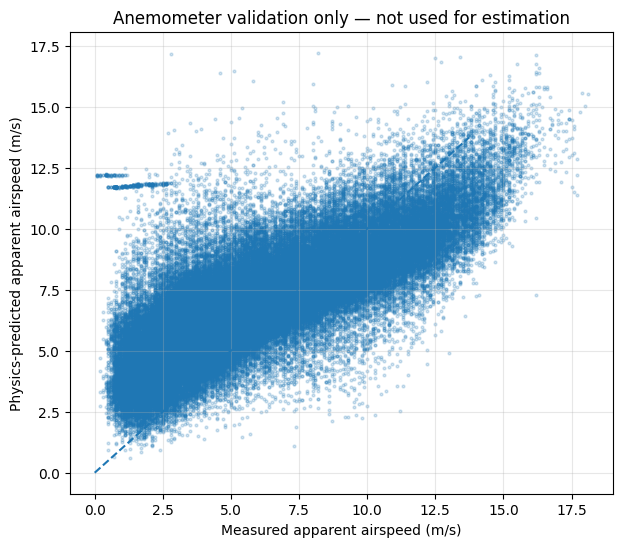

In [15]:
validation = physics_df.loc[
    physics_df["Physics_sample_valid"]
    & physics_df["Wind_speed"].notna()
    & physics_df["Predicted_apparent_airspeed_mps"].notna()
].copy()

# The anemometer is kept only as a check. It was not used by the physics estimator.
if len(validation) < 2:
    print("Not enough valid anemometer samples for validation.")
else:
    actual = validation["Wind_speed"].to_numpy()
    predicted = validation["Predicted_apparent_airspeed_mps"].to_numpy()

    correlation = (
        float(np.corrcoef(actual, predicted)[0, 1])
        if np.std(actual) > 0 and np.std(predicted) > 0
        else np.nan
    )
    validation_metrics = {
        "sample_count": len(validation),
        "MAE_mps": mean_absolute_error(actual, predicted),
        "RMSE_mps": mean_squared_error(actual, predicted) ** 0.5,
        "correlation": correlation,
    }
    display(pd.Series(validation_metrics, name="value").to_frame())

    # Diagnostic scatter plot. A perfect model would follow the dashed 1:1 line.
    plt.figure(figsize=(7, 6))
    plt.scatter(actual, predicted, s=4, alpha=0.2)
    maximum = float(np.nanpercentile(np.r_[actual, predicted], 99))
    plt.plot([0, maximum], [0, maximum], "--")
    plt.xlabel("Measured apparent airspeed (m/s)")
    plt.ylabel("Physics-predicted apparent airspeed (m/s)")
    plt.title("Anemometer validation only — not used for estimation")
    plt.grid(True, alpha=0.3)
    plt.show()

## Cell 13 — Choose the flight(s) used to create the 3D field



In [16]:
available_flights = sorted(physics_df["Flight_ID"].unique().tolist())
print("Available flight IDs:", available_flights[:30], "..." if len(available_flights) > 30 else "")

# Replace with one or more flight IDs. Start with one flight while calibrating.
MAP_FLIGHT_IDS = [available_flights[0]]

map_samples = physics_df.loc[
    physics_df["Flight_ID"].isin(MAP_FLIGHT_IDS)
    & physics_df["Physics_sample_valid"]
].copy()
map_samples.sort_values(["Flight_ID", "Elapsed_s"], inplace=True)

# Use a single geographic origin for every selected flight.
# This avoids placing each flight at its own independent (0, 0, 0) origin.
reference_flight = MAP_FLIGHT_IDS[0]
reference_rows = (
    physics_df.loc[physics_df["Flight_ID"] == reference_flight]
    .sort_values("Elapsed_s")
    .head(10)
)
map_longitude_0 = float(reference_rows["X"].median())
map_latitude_0 = float(reference_rows["Y"].median())
map_altitude_0 = float(reference_rows["Z"].median())
map_mean_latitude_rad = np.deg2rad((map_samples["Y"] + map_latitude_0) / 2.0)

map_samples["Map_east_m"] = (
    EARTH_RADIUS_M
    * np.deg2rad(map_samples["X"] - map_longitude_0)
    * np.cos(map_mean_latitude_rad)
)
map_samples["Map_north_m"] = (
    EARTH_RADIUS_M * np.deg2rad(map_samples["Y"] - map_latitude_0)
)
map_samples["Map_up_m"] = map_samples["Z"] - map_altitude_0

# Reduce spatial over-clustering while preserving each flight's time ordering.
SAMPLE_STRIDE = 3
keep_indices = []
for _, group in map_samples.groupby("Flight_ID", sort=True):
    keep_indices.extend(group.index[::SAMPLE_STRIDE].tolist())
map_samples = map_samples.loc[keep_indices].copy()
map_samples.sort_values(["Flight_ID", "Elapsed_s"], inplace=True)
map_samples.reset_index(drop=True, inplace=True)

required_map_columns = [
    "Map_east_m", "Map_north_m", "Map_up_m",
    "Physics_wind_east_mps", "Physics_wind_north_mps", "Physics_wind_up_mps",
]
map_samples.dropna(subset=required_map_columns, inplace=True)

print(f"Using {len(map_samples):,} wind samples from flights {MAP_FLIGHT_IDS}")
display(map_samples[required_map_columns + ["Physics_wind_speed_mps"]].describe())

if len(map_samples) < 20:
    raise ValueError("Too few valid samples. Choose another flight or loosen a justified quality threshold.")

Available flight IDs: [1, 2, 3, 4, 5, 6, 7, 8, 10, 12, 14, 15, 16, 17, 18, 20, 23, 59, 60, 68, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85] ...
Using 250 wind samples from flights [1]


,Map_east_m,Map_north_m,Map_up_m,Physics_wind_east_mps,Physics_wind_north_mps,Physics_wind_up_mps,Physics_wind_speed_mps
count,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000
mean,19.911106,81.613297,21.094717,-1.555973,2.495734,-0.318072,3.950754
std,36.935514,61.496673,4.075460,1.601157,1.757519,1.882237,1.519969
min,-35.805429,-1.877284,5.275761,-5.936129,-4.305398,-4.602810,1.013773
25%,-5.494232,18.668010,19.703339,-2.403811,1.469504,-1.822996,3.054625
50%,3.951438,83.589774,22.317543,-1.744143,2.562619,-0.450479,3.797441
75%,49.838603,137.784827,23.879405,-1.031464,3.168960,1.002094,4.559028
max,95.751886,179.680677,26.252279,9.346689,11.293627,4.376041,11.500106


## Cell 14 — Create a PyVista point cloud and interpolate it onto a 3D grid



In [17]:
# Sparse calculated samples along the selected flight path(s).
sample_points = map_samples[[
    "Map_east_m", "Map_north_m", "Map_up_m"
]].to_numpy(dtype=float)
wind_vectors = map_samples[[
    "Physics_wind_east_mps", "Physics_wind_north_mps", "Physics_wind_up_mps"
]].to_numpy(dtype=float)

wind_cloud = pv.PolyData(sample_points)
wind_cloud["WindVector"] = wind_vectors
wind_cloud["WindSpeed"] = np.linalg.norm(wind_vectors, axis=1)
wind_cloud.set_active_vectors("WindVector")

# Grid resolution. Increase carefully; memory scales as NX * NY * NZ.
NX, NY, NZ = 28, 28, 18
padding_m = 3.0

mins = sample_points.min(axis=0) - padding_m
maxs = sample_points.max(axis=0) + padding_m
spans = np.maximum(maxs - mins, 1.0)
spacing = (
    spans[0] / (NX - 1),
    spans[1] / (NY - 1),
    spans[2] / (NZ - 1),
)

grid = pv.ImageData(
    dimensions=(NX, NY, NZ),
    spacing=spacing,
    origin=tuple(mins),
)

# Gaussian interpolation estimates vectors only near actual flight samples.
# vtkValidPointMask marks supported versus unsupported grid points.
INTERPOLATION_RADIUS_M = max(2.5 * max(spacing), 8.0)
INTERPOLATION_SHARPNESS = 3.0

wind_grid = grid.interpolate(
    wind_cloud,
    radius=INTERPOLATION_RADIUS_M,
    sharpness=INTERPOLATION_SHARPNESS,
    strategy="mask_points",
    null_value=0.0,
)

if "WindVector" not in wind_grid.array_names:
    raise RuntimeError("PyVista interpolation did not create the WindVector array.")

wind_grid["WindSpeed"] = np.linalg.norm(wind_grid["WindVector"], axis=1)
wind_grid.set_active_vectors("WindVector")

valid_grid_mask = wind_grid["vtkValidPointMask"].astype(bool)
if not valid_grid_mask.any():
    raise RuntimeError("No grid points are supported. Increase INTERPOLATION_RADIUS_M.")

print("Grid points:", wind_grid.n_points)
print("Supported grid points:", int(valid_grid_mask.sum()))
print("Interpolation radius (m):", INTERPOLATION_RADIUS_M)

# Save the VTK field so it can be opened in ParaView or PyVista later.
wind_grid_path = OUTPUT_DIR / "physics_wind_field.vti"
wind_grid.save(wind_grid_path)
print("Saved:", wind_grid_path)

Grid points: 14112
Supported grid points: 5703
Interpolation radius (m): 17.366477811892278
Saved: /content/physics_wind_output/physics_wind_field.vti


## Cell 15 — Build PyVista arrow glyphs and streamlines

In [18]:
# Extract only supported grid-point IDs for arrows.
# Build a new PolyData explicitly so vector/scalar arrays survive thinning.
supported_point_ids = np.flatnonzero(valid_grid_mask)
GLYPH_STRIDE = max(1, len(supported_point_ids) // 600)
glyph_grid_ids = supported_point_ids[::GLYPH_STRIDE]

glyph_points = pv.PolyData(wind_grid.points[glyph_grid_ids])
glyph_points["WindVector"] = wind_grid["WindVector"][glyph_grid_ids]
glyph_points["WindSpeed"] = wind_grid["WindSpeed"][glyph_grid_ids]
glyph_points.set_active_vectors("WindVector")

# Arrow length is proportional to wind speed.
GLYPH_FACTOR = 0.35
wind_arrows = glyph_points.glyph(
    orient="WindVector",
    scale="WindSpeed",
    factor=GLYPH_FACTOR,
)

# Keep trajectories separate so multiple flights are not connected by a false line.
trajectories = []
for flight_id, group in map_samples.groupby("Flight_ID", sort=True):
    flight_points = group[["Map_east_m", "Map_north_m", "Map_up_m"]].to_numpy(dtype=float)
    if len(flight_points) >= 2:
        trajectories.append((flight_id, pv.Spline(flight_points, n_points=len(flight_points))))

# Use a subset of actual flight positions as streamline seeds.
seed_stride = max(1, len(sample_points) // 35)
streamline_seeds = pv.PolyData(sample_points[::seed_stride])

try:
    streamlines = wind_grid.streamlines_from_source(
        streamline_seeds,
        vectors="WindVector",
        integration_direction="both",
        integrator_type=45,
        initial_step_length=0.3,
        max_step_length=1.0,
        terminal_speed=0.05,
        max_length=float(np.linalg.norm(spans) * 1.5),
        compute_vorticity=False,
    )
    print("Streamline cells:", streamlines.n_cells)
except Exception as exc:
    warnings.warn(f"Streamline generation failed; arrows will still work. {exc}")
    streamlines = pv.PolyData()

Streamline cells: 72


## Cell 16 — Render the 3D wind map in Colab

In [22]:
# ============================================================
# CELL 16A — BUILD THE PYVISTA WIND SCENE
# ============================================================
# This function adds all wind-map objects to any new plotter.
# Using a function lets us create:
#   1. one plotter for exporting
#   2. another plotter for displaying in Colab
#
# This avoids trying to reuse a plotter whose render window
# may already have been destroyed.

def add_wind_scene(plotter):
    """Add the full physics-based 3D wind visualization."""

    plotter.set_background("white")

    # --------------------------------------------------------
    # Add each drone trajectory separately.
    # Keeping flights separate prevents PyVista from drawing
    # an artificial connecting line between different flights.
    # --------------------------------------------------------
    for index, (flight_id, trajectory) in enumerate(trajectories):
        plotter.add_mesh(
            trajectory,
            color="black",
            line_width=4,
            label="Drone path" if index == 0 else None,
        )

    # --------------------------------------------------------
    # Add the original physics-calculated wind samples.
    # Point color represents wind magnitude.
    # --------------------------------------------------------
    plotter.add_mesh(
        wind_cloud,
        scalars="WindSpeed",
        cmap="viridis",
        point_size=7,
        render_points_as_spheres=True,
        opacity=0.65,
        show_scalar_bar=False,
    )

    # --------------------------------------------------------
    # Add wind-vector arrows.
    # Direction represents the 3D wind-vector direction.
    # Arrow length represents wind speed.
    # Arrow color also represents wind speed.
    # --------------------------------------------------------
    plotter.add_mesh(
        wind_arrows,
        scalars="WindSpeed",
        cmap="viridis",
        lighting=False,
        scalar_bar_args={
            "title": "Wind speed (m/s)"
        },
    )

    # --------------------------------------------------------
    # Add streamlines when streamline generation succeeded.
    # Streamlines show the predicted paths that particles
    # would follow through the interpolated wind field.
    # --------------------------------------------------------
    if streamlines.n_cells > 0:
        streamline_tubes = streamlines.tube(
            radius=max(spacing) * 0.08
        )

        streamline_scalars = (
            "WindSpeed"
            if "WindSpeed" in streamline_tubes.array_names
            else None
        )

        plotter.add_mesh(
            streamline_tubes,
            scalars=streamline_scalars,
            cmap="viridis",
            opacity=0.75,
            show_scalar_bar=False,
        )

    # Outline of the interpolated 3D wind volume.
    plotter.add_mesh(
        wind_grid.outline(),
        color="gray",
        line_width=1,
    )

    # Coordinate system:
    # X = East
    # Y = North
    # Z = Up
    plotter.add_axes(
        xlabel="East (m)",
        ylabel="North (m)",
        zlabel="Up (m)",
    )

    plotter.add_legend()

    # Start with an isometric view.
    plotter.camera_position = "iso"
    plotter.reset_camera()

    return plotter


print("Wind-scene function created.")

Wind-scene function created.


In [23]:
# ============================================================
# CELL 16B — EXPORT THE INTERACTIVE WIND SCENE
# ============================================================
# IMPORTANT:
# This plotter is exported BEFORE show() is called.
#
# Do not call:
#     export_plotter.show()
#
# before export_vtksz() or export_html().

from pathlib import Path
import shutil
import pyvista as pv

OUTPUT_DIR = Path("/content/physics_wind_results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

png_path = OUTPUT_DIR / "physics_3D_wind_map.png"
html_path = OUTPUT_DIR / "physics_3D_wind_map.html"
vtksz_path = OUTPUT_DIR / "physics_3D_wind_scene.vtksz"

# ------------------------------------------------------------
# Create a completely new plotter.
# We do not reuse the old `plotter` variable.
# ------------------------------------------------------------
export_plotter = pv.Plotter(
    notebook=True,
    off_screen=True,
    window_size=(1100, 800),
)

# Add all scene objects.
add_wind_scene(export_plotter)

# Check that the plotter is still alive.
if export_plotter.render_window is None:
    raise RuntimeError(
        "The new export plotter was unexpectedly closed."
    )

print("Export plotter is active.")

# Render internally without opening or closing a display window.
export_plotter.render()

# ------------------------------------------------------------
# Export the Kitware OfflineLocalView scene.
# This is the file you upload when the Kitware page asks
# you to choose a scene.
# ------------------------------------------------------------
export_plotter.export_vtksz(str(vtksz_path))
print("Saved VTKSZ:", vtksz_path)

# Export a self-contained interactive HTML version.
export_plotter.export_html(str(html_path))
print("Saved HTML:", html_path)

# Export a static preview image.
export_plotter.screenshot(str(png_path))
print("Saved PNG:", png_path)

# Close only after every export is finished.
export_plotter.close()

print("\nAll scene exports completed successfully.")

Export plotter is active.
Saved VTKSZ: /content/physics_wind_results/physics_3D_wind_scene.vtksz
Saved HTML: /content/physics_wind_results/physics_3D_wind_map.html
Saved PNG: /content/physics_wind_results/physics_3D_wind_map.png

All scene exports completed successfully.


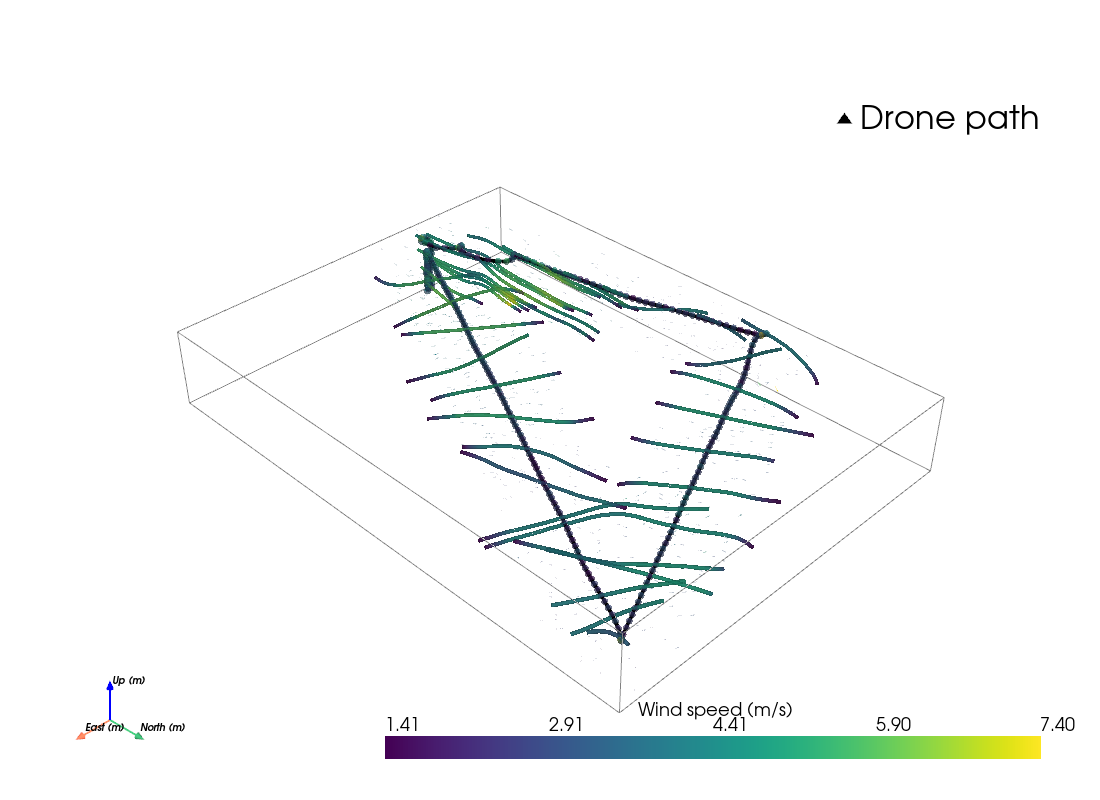

In [24]:
# ============================================================
# CELL 16C — DISPLAY A STATIC PREVIEW IN COLAB
# ============================================================
# This is a separate plotter from export_plotter.
# It is safe for this one to call show() because all files
# have already been exported.

preview_plotter = pv.Plotter(
    notebook=True,
    window_size=(1100, 800),
)

add_wind_scene(preview_plotter)

preview_plotter.show(
    jupyter_backend="static"
)

## Cell 17 — Save a PNG and an interactive HTML scene

In [25]:
# ============================================================
# CELL 17 — PACKAGE AND DOWNLOAD THE RESULTS
# ============================================================

from pathlib import Path
import shutil
from google.colab import files

OUTPUT_DIR = Path("/content/physics_wind_results")

# Verify that the required interactive scene was created.
vtksz_path = OUTPUT_DIR / "physics_3D_wind_scene.vtksz"

if not vtksz_path.exists():
    raise FileNotFoundError(
        "physics_3D_wind_scene.vtksz was not created. "
        "Rerun Cell 16B."
    )

print("VTKSZ size:", vtksz_path.stat().st_size, "bytes")

# Create a ZIP containing all results.
results_zip_path = shutil.make_archive(
    "/content/physics_wind_results",
    "zip",
    root_dir=OUTPUT_DIR,
)

print("Created ZIP:", results_zip_path)

# Download the complete results package.
files.download(results_zip_path)

VTKSZ size: 1566935 bytes
Created ZIP: /content/physics_wind_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Cell 18 — Calibration checklist before reporting scientific results

1. Supply the correct payload mass for every flight.
2. Measure or estimate `CdA` separately for body x, y, and z.
3. Validate the power-to-thrust estimate using a load cell or motor/propeller thrust stand.
4. Compare predicted apparent airspeed against the onboard anemometer without fitting to the validation flights.
5. Inspect results by flight phase; takeoff, landing, sharp turns, and ground effect should normally be excluded.
6. Do not interpret interpolated regions beyond the PyVista valid-point mask.
7. For a stronger 3D estimator, record motor RPM or ESC telemetry in future flights. That removes the largest uncertainty in the present model.